# Project 2: Dynamic Programming for Airline Overbooking

## Problem Overview

We work for an airline pricing department and want to find the optimal pricing and overbooking policy for a flight with **100 coach seats** and **20 first-class seats**. There are **365 days** to sell tickets before departure. Each day we choose a coach price and a first-class price, and at most one ticket in each class can be sold. Overbooking in first class is not allowed, but coach can be oversold. On departure day, passengers who show up beyond capacity are either **bumped to first class (\$50 cost)** or **denied boarding (\$425 cost)**.

We solve this using **backward induction (dynamic programming)** to maximize expected discounted profit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import binom
from IPython.display import display, Markdown
%matplotlib inline

---
## Part 1: Fixed Coach Overbooking Cap of 5 Seats

> **Question:** Allow coach to be oversold by 5 seats (max 105 coach tickets). What is the expected discounted profit of selling these tickets and paying out overbooking costs over the course of the year?

### Approach

We model this as a **finite-horizon stochastic dynamic program**. The state is (t, c, f) — the current day, coach tickets sold, and first-class tickets sold. Each day we choose one of 6 price combinations, which determines the probability of selling a ticket in each class. We solve it via **backward induction** starting from the departure day:

1. **Terminal condition (day 365):** No more sales — we only compute the expected overbooking cost. We use the **binomial distribution** (`scipy.stats.binom`) since each ticket holder independently shows up with probability 0.95 (coach) or 0.97 (first class). For each possible number of coach and first-class show-ups, we calculate how many passengers get bumped to first class (\$50 each) vs. denied boarding (\$425 each).

2. **Bellman equation (days 364 → 0):** At each state, we try all 6 price combos and pick the one that maximizes **expected revenue today + discounted expected future value**. Each combo leads to 4 possible outcomes (coach sells or not × first class sells or not), each with a known probability.

In [2]:
# ── Parameters ──
T = 365                  # days to sell tickets before departure
coach_seats = 100        # physical coach seats on the plane
first_class_seats = 20   # physical first-class seats
overbooking_limit = 5    # can oversell coach by this many
max_coach = coach_seats + overbooking_limit  # 105

# Coach pricing options
low_coach_price = 300;   low_coach_prob = 0.65
med_coach_price = 325;   med_coach_prob = 0.45
high_coach_price = 350;  high_coach_prob = 0.30

# First-class pricing options
low_first_price = 425;   low_first_prob = 0.08
high_first_price = 500;  high_first_prob = 0.04

# Show-up probabilities and overbooking costs
coach_show_prob = 0.95
first_show_prob = 0.97
bump_to_fc_cost = 50       # bump coach passenger to first class
bump_off_plane_cost = 425  # deny boarding entirely

# Discount factor (17% annual rate)
discount = 1 / (1 + 0.17 / 365)

# +4 pct pt boost to coach sale prob when first class is sold out
fc_sold_out_boost = 0.04

# All 6 price combinations: (coach_price, coach_prob, first_price, first_prob)
choices = [
    (low_coach_price,  low_coach_prob,  low_first_price,  low_first_prob),   # $300C + $425F
    (low_coach_price,  low_coach_prob,  high_first_price, high_first_prob),  # $300C + $500F
    (med_coach_price,  med_coach_prob,  low_first_price,  low_first_prob),   # $325C + $425F
    (med_coach_price,  med_coach_prob,  high_first_price, high_first_prob),  # $325C + $500F
    (high_coach_price, high_coach_prob, low_first_price,  low_first_prob),   # $350C + $425F
    (high_coach_price, high_coach_prob, high_first_price, high_first_prob),  # $350C + $500F
]
choice_labels = [f"${cp}C+${fp}F" for cp, _, fp, _ in choices]
print(choices)

[(300, 0.65, 425, 0.08), (300, 0.65, 500, 0.04), (325, 0.45, 425, 0.08), (325, 0.45, 500, 0.04), (350, 0.3, 425, 0.08), (350, 0.3, 500, 0.04)]


In [3]:
# ── Initialize value function and policy arrays ──
V = np.zeros((T+1, max_coach+1, first_class_seats+1))  # V[t, c, f]
U = np.zeros((T+1, max_coach+1, first_class_seats+1), dtype=int)  # U[t, c, f] stores best choice (1-indexed)

### Terminal Condition (Day 365)

On departure day there is no more revenue — only overbooking costs. For each possible state (c, f), we compute the **expected cost** by summing over all possible show-up combinations using the binomial distribution. The key logic: overflow coach passengers first fill empty first-class seats (\$50 bump cost), and any remaining are denied boarding (\$425).

In [4]:
# ── Terminal condition: expected overbooking cost at departure ──
for c in range(max_coach + 1):  # for every possible number of coach tickets sold
    for f in range(first_class_seats + 1):  # for every possible number of FC tickets sold
        cost_expected = 0
        p_coach = binom.pmf(range(c+1), c, coach_show_prob)   # prob of 0,1,...,c coach showing up
        p_first = binom.pmf(range(f+1), f, first_show_prob)   # prob of 0,1,...,f FC showing up
        for i in range(c + 1):       # for each possible number of coach passengers showing up
            for j in range(f + 1):   # for each possible number of FC passengers showing up
                p_ij = p_coach[i] * p_first[j]              # joint probability (independent)
                overflow = max(0, i - coach_seats)           # coach passengers without a seat
                fc_empty = max(0, first_class_seats - j)     # empty first-class seats available
                bumped = min(overflow, fc_empty)              # bumped to FC at $50 each
                denied = overflow - bumped                   # denied boarding at $425 each
                cost = bumped * bump_to_fc_cost + denied * bump_off_plane_cost
                cost_expected += p_ij * cost
        V[T, c, f] = -cost_expected  # negative because it's a cost (we maximize profit)

print(f"Terminal cost if 105 coach + 20 FC sold: ${-V[T, 105, 20]:,.2f}")
print(f"Terminal cost if 100 coach + 20 FC sold: ${-V[T, 100, 20]:,.2f}")  # no overbooking

Terminal cost if 105 coach + 20 FC sold: $240.93
Terminal cost if 100 coach + 20 FC sold: $0.00


### Bellman Equation (Backward Induction)

We loop backwards from t=364 to t=0. At each state (t, c, f), we evaluate all 6 price combinations. For each combo, the value is:

$$\text{profit} = \underbrace{p_c \cdot \text{coach\_price} + p_f \cdot \text{first\_price}}_{\text{expected revenue today}} + \delta \cdot \underbrace{\sum_{\text{4 outcomes}} P(\text{outcome}) \cdot V[t+1, \text{next state}]}_{\text{discounted expected future value}}$$

We store the best choice in `U[t, c, f]` (1-indexed) and the best value in `V[t, c, f]`. When both classes are sold out, there's no choice to make — we just carry forward the discounted future value.

In [5]:
# ── Backward induction ──
for t in reversed(range(T)):  # loop backwards in time
    for c in range(max_coach + 1):  # for each possible coach tickets sold
        for f in range(first_class_seats + 1):  # for each possible FC tickets sold
            coach_full = (c == max_coach)        # hit the ticket cap
            fc_full = (f == first_class_seats)   # first class sold out
            
            # if both full, no revenue today, just carry forward
            if coach_full and fc_full:
                V[t, c, f] = discount * V[t+1, c, f]
                U[t, c, f] = 0
                continue
            
            best_profit = -np.inf
            best_choice = 0
            
            for idx, (cp, c_prob, fp, f_prob) in enumerate(choices):
                # sale probabilities
                prob_coach = 0 if coach_full else c_prob
                prob_first = 0 if fc_full else f_prob
                
                # boost coach prob when FC is sold out
                if fc_full and not coach_full:
                    prob_coach = min(1, prob_coach + fc_sold_out_boost)
                
                # next states
                c_next = min(c + 1, max_coach)
                f_next = min(f + 1, first_class_seats)
                
                # expected revenue today
                today_rev = prob_coach * cp + prob_first * fp
                
                # expected discounted future value (4 outcomes)
                future_val = (
                    (1-prob_coach) * (1-prob_first) * V[t+1, c,      f]      +  # no sales
                    (prob_coach)   * (1-prob_first) * V[t+1, c_next, f]      +  # coach only
                    (1-prob_coach) * (prob_first)   * V[t+1, c,      f_next] +  # FC only
                    (prob_coach)   * (prob_first)   * V[t+1, c_next, f_next]    # both sell
                )
                
                profit = today_rev + discount * future_val
                
                if profit > best_profit:
                    best_profit = profit
                    best_choice = idx + 1  # 1-indexed like in class
            
            V[t, c, f] = best_profit
            U[t, c, f] = best_choice

print(f"Expected discounted profit (overbooking cap = 5): ${V[0, 0, 0]:,.2f}")

Expected discounted profit (overbooking cap = 5): $41,909.75


/var/folders/nm/56b8xk6x7ts8dv44chwwjbth0000gn/T/ipykernel_97399/839121132.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap6 = plt.cm.get_cmap('tab10', 6)


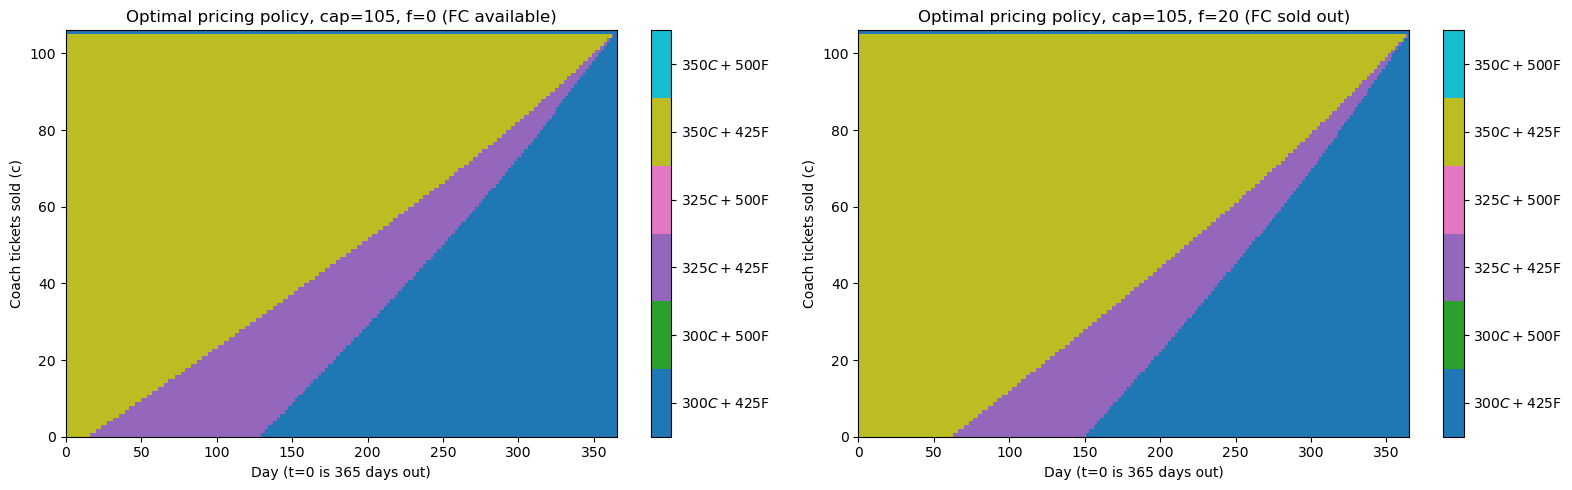

In [6]:
# ── Policy heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cmap6 = plt.cm.get_cmap('tab10', 6)

for ax, f_val, label in zip(axes, [0, 20], ['f=0 (FC available)', 'f=20 (FC sold out)']):
    im = ax.pcolormesh(U[:T, :, f_val].T, cmap=cmap6, vmin=0.5, vmax=6.5)
    cbar = fig.colorbar(im, ax=ax, ticks=range(1, 7))
    cbar.ax.set_yticklabels(choice_labels)
    ax.set_xlabel('Day (t=0 is 365 days out)')
    ax.set_ylabel('Coach tickets sold (c)')
    ax.set_title(f'Optimal pricing policy, cap=105, {label}')

plt.tight_layout()
plt.show()

**Interpretation:** Early on, the airline prices coach low (\$300) to fill seats. As coach fills up, the policy shifts to higher prices (\$325, \$350) to slow sales and manage overbooking risk. When first class is sold out (right panel), the 4-point coach probability boost causes the airline to shift to higher prices slightly earlier.

---
## Part 2: Optimal Overbooking Cap (5 to 20 Seats)

> **Question:** Repeat the analysis allowing coach to be oversold by 6, 7, 8, ..., 20 seats. Which overbooking policy leads to the largest profits?

### Approach

We need to solve the exact same DP 16 times (once per cap from 5 to 20), so we wrap the Part 1 logic into a reusable function `solve_dp()`. The only thing that changes between runs is `max_coach` (the ticket ceiling). For each cap, we record V[0,0,0] — the expected profit starting from no tickets sold on day 0. The cap with the highest value is the optimal overbooking policy.

In [7]:
def solve_dp(overbooking_limit, choices_list, time_varying=False):
    """Solve the DP for a given overbooking limit. Returns V, U, and initial profit."""
    max_c = coach_seats + overbooking_limit
    
    V = np.zeros((T+1, max_c+1, first_class_seats+1))
    U = np.zeros((T+1, max_c+1, first_class_seats+1), dtype=int)
    
    # terminal condition
    for c in range(max_c + 1):
        for f in range(first_class_seats + 1):
            cost_expected = 0
            p_coach = binom.pmf(range(c+1), c, coach_show_prob)
            p_first = binom.pmf(range(f+1), f, first_show_prob)
            for i in range(c + 1):
                for j in range(f + 1):
                    p_ij = p_coach[i] * p_first[j]
                    overflow = max(0, i - coach_seats)
                    fc_empty = max(0, first_class_seats - j)
                    bumped = min(overflow, fc_empty)
                    denied = overflow - bumped
                    cost = bumped * bump_to_fc_cost + denied * bump_off_plane_cost
                    cost_expected += p_ij * cost
            V[T, c, f] = -cost_expected
    
    # bellman equation
    for t in reversed(range(T)):
        factor = (0.75 + t / 730) if time_varying else 1.0
        for c in range(max_c + 1):
            for f in range(first_class_seats + 1):
                coach_full = (c == max_c)
                fc_full = (f == first_class_seats)
                if coach_full and fc_full:
                    V[t, c, f] = discount * V[t+1, c, f]
                    U[t, c, f] = 0
                    continue
                best_profit = -np.inf
                best_choice = 0
                for idx, (cp, c_prob, fp, f_prob) in enumerate(choices_list):
                    prob_coach = 0 if coach_full else min(1, c_prob * factor)
                    prob_first = 0 if fc_full else min(1, f_prob * factor)
                    if fc_full and not coach_full and c_prob > 0:
                        prob_coach = min(1, prob_coach + fc_sold_out_boost)
                    c_next = min(c + 1, max_c)
                    f_next = min(f + 1, first_class_seats)
                    today_rev = prob_coach * cp + prob_first * fp
                    future_val = (
                        (1-prob_coach)*(1-prob_first)*V[t+1, c, f] +
                        prob_coach*(1-prob_first)*V[t+1, c_next, f] +
                        (1-prob_coach)*prob_first*V[t+1, c, f_next] +
                        prob_coach*prob_first*V[t+1, c_next, f_next]
                    )
                    profit = today_rev + discount * future_val
                    if profit > best_profit:
                        best_profit = profit
                        best_choice = idx + 1
                V[t, c, f] = best_profit
                U[t, c, f] = best_choice
    
    return V, U, round(V[0, 0, 0], 2)

In [8]:
# check: should match Part 1 answer
solve_dp(5, choices)[2]

np.float64(41909.75)

In [9]:
# sweep overbooking caps from 5 to 20
results = {}
for ob in range(5, 21):
    V_ob, U_ob, profit_ob = solve_dp(ob, choices)
    results[ob] = {'V': V_ob, 'U': U_ob, 'profit': profit_ob}
    print(f"Overbooking limit: {ob:2d}, Expected profit: ${profit_ob:,.2f}")

best_ob = max(results, key=lambda k: results[k]['profit'])
print(f"\nOptimal overbooking limit: {best_ob} seats")
print(f"Optimal expected profit: ${results[best_ob]['profit']:,.2f}")

Overbooking limit:  5, Expected profit: $41,909.75
Overbooking limit:  6, Expected profit: $42,039.02
Overbooking limit:  7, Expected profit: $42,117.95
Overbooking limit:  8, Expected profit: $42,157.77
Overbooking limit:  9, Expected profit: $42,171.35
Overbooking limit: 10, Expected profit: $42,169.24
Overbooking limit: 11, Expected profit: $42,158.86
Overbooking limit: 12, Expected profit: $42,144.91
Overbooking limit: 13, Expected profit: $42,130.13
Overbooking limit: 14, Expected profit: $42,115.88
Overbooking limit: 15, Expected profit: $42,102.78
Overbooking limit: 16, Expected profit: $42,091.04
Overbooking limit: 17, Expected profit: $42,080.72
Overbooking limit: 18, Expected profit: $42,071.78
Overbooking limit: 19, Expected profit: $42,064.15
Overbooking limit: 20, Expected profit: $42,057.69

Optimal overbooking limit: 9 seats
Optimal expected profit: $42,171.35


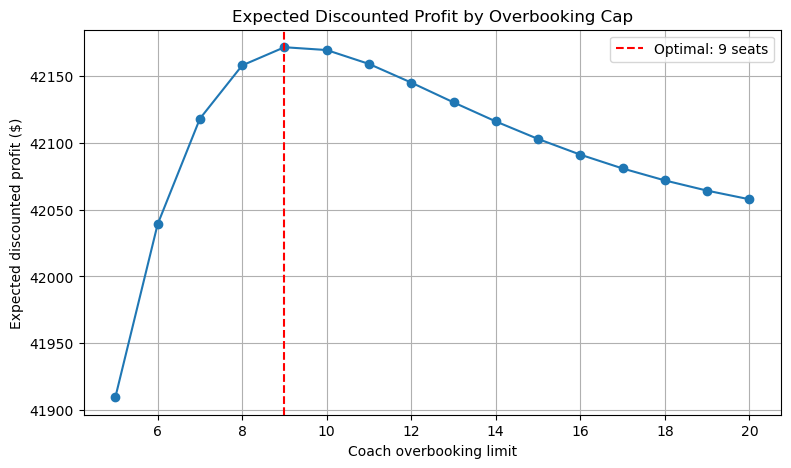

In [10]:
# plot profit vs overbooking cap
ob_range = list(range(5, 21))
profits_list = [results[ob]['profit'] for ob in ob_range]

plt.figure(figsize=(9, 5))
plt.plot(ob_range, profits_list, marker='o')
plt.axvline(x=best_ob, color='red', linestyle='--', label=f'Optimal: {best_ob} seats')
plt.xlabel('Coach overbooking limit')
plt.ylabel('Expected discounted profit ($)')
plt.title('Expected Discounted Profit by Overbooking Cap')
plt.legend()
plt.grid(True)
plt.show()

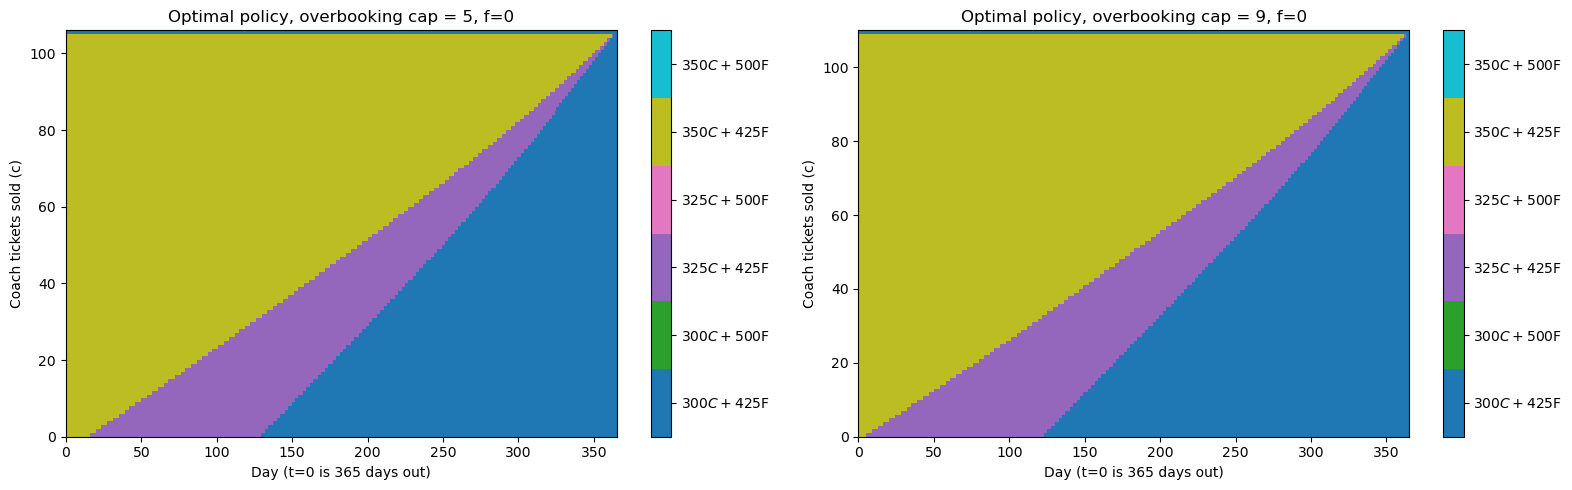

In [11]:
# side-by-side policy heatmaps: cap=5 vs best cap
V_best, U_best = results[best_ob]['V'], results[best_ob]['U']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, U_plot, ob_label in zip(axes, [U, U_best], [5, best_ob]):
    im = ax.pcolormesh(U_plot[:T, :, 0].T, cmap=cmap6, vmin=0.5, vmax=6.5)
    cbar = fig.colorbar(im, ax=ax, ticks=range(1, 7))
    cbar.ax.set_yticklabels(choice_labels)
    ax.set_xlabel('Day (t=0 is 365 days out)')
    ax.set_ylabel('Coach tickets sold (c)')
    ax.set_title(f'Optimal policy, overbooking cap = {ob_label}, f=0')
plt.tight_layout()
plt.show()

**Interpretation:** Profit rises steeply from oversell=5 to the optimal level, then gradually declines. Beyond the optimum, increasing overbooking penalties outweigh the marginal ticket revenue. The concave shape confirms a clear interior optimum. The policy heatmaps are similar but the optimal cap extends the state space further on the y-axis.

---
## Part 3: Flexible Policy with No-Sale Option

> **Question:** Consider a new policy where the airline can choose to sell no coach tickets on a given day (4 coach actions: high, medium, low, no sale). Max 130 coach seats. Does this have better or worse expected profit than the best hard-cap policy from Part 2?

### Approach

We expand the action space from 6 choices to **8 choices** by adding two "no sale" options (no coach sale + low FC price, no coach sale + high FC price). The "no sale" action sets coach price and probability to 0, so no coach ticket can be sold that day. The state space also expands: `max_coach = 130` instead of the hard cap. This lets the DP **dynamically decide** when to stop selling coach based on the current state, rather than being forced to stop at a fixed cap. We then compare V[0,0,0] between this flexible policy and the best hard cap from Part 2.

In [12]:
# 8 choices: original 6 + 2 "no sale" options for coach
choices_flex = choices + [
    (0, 0, low_first_price,  low_first_prob),   # No coach sale + $425F
    (0, 0, high_first_price, high_first_prob),  # No coach sale + $500F
]
choice_labels_flex = choice_labels + ["NoSale+$425F", "NoSale+$500F"]

V_flex, U_flex, profit_flex = solve_dp(30, choices_flex)  # overbooking_limit=30 -> max 130 coach

print(f"Best hard-cap policy (OB={best_ob}):   ${results[best_ob]['profit']:,.2f}")
print(f"Flexible no-sale policy (cap=130): ${profit_flex:,.2f}")
print(f"Improvement:                       ${profit_flex - results[best_ob]['profit']:,.2f}")

Best hard-cap policy (OB=9):   $42,171.35
Flexible no-sale policy (cap=130): $42,177.14
Improvement:                       $5.79


% of states where no-sale is chosen (f=0): 7.0%


/var/folders/nm/56b8xk6x7ts8dv44chwwjbth0000gn/T/ipykernel_97399/2373166517.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap8 = plt.cm.get_cmap('tab10', 8)


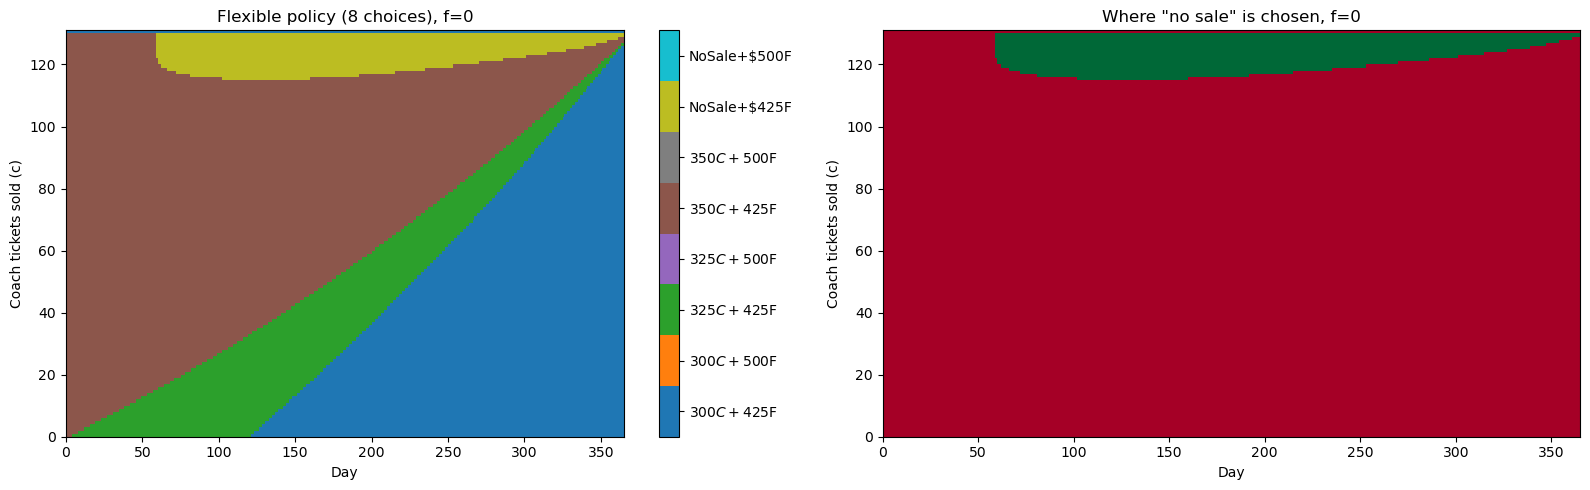

In [13]:
# where does the no-sale action get used?
no_sale_mask = (U_flex[:T, :, 0] >= 7)
print(f"% of states where no-sale is chosen (f=0): {no_sale_mask.mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# full policy heatmap
cmap8 = plt.cm.get_cmap('tab10', 8)
im = axes[0].pcolormesh(U_flex[:T, :, 0].T, cmap=cmap8, vmin=0.5, vmax=8.5)
cbar = fig.colorbar(im, ax=axes[0], ticks=range(1, 9))
cbar.ax.set_yticklabels(choice_labels_flex)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Coach tickets sold (c)')
axes[0].set_title('Flexible policy (8 choices), f=0')

# highlight no-sale regions
axes[1].pcolormesh(no_sale_mask.T, cmap='RdYlGn')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Coach tickets sold (c)')
axes[1].set_title('Where "no sale" is chosen, f=0')

plt.tight_layout()
plt.show()

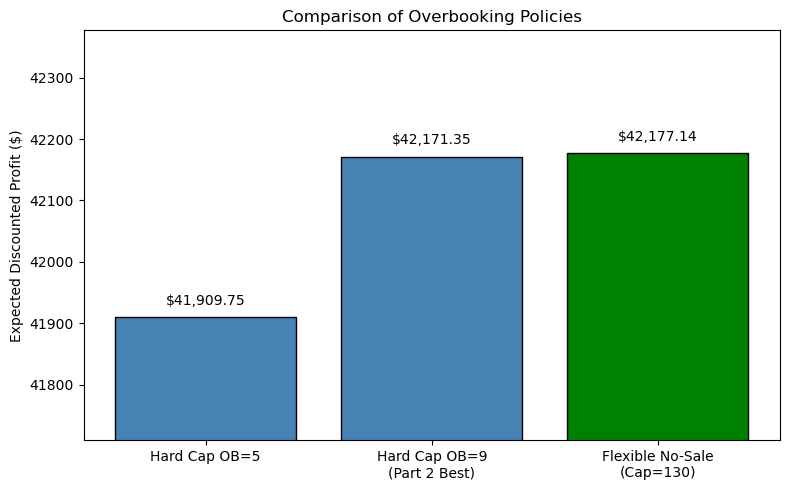

In [14]:
# bar chart comparison of all three policies
policies = ['Hard Cap OB=5', f'Hard Cap OB={best_ob}\n(Part 2 Best)', 'Flexible No-Sale\n(Cap=130)']
profits_bar = [round(V[0,0,0], 2), results[best_ob]['profit'], profit_flex]

plt.figure(figsize=(8, 5))
bars = plt.bar(policies, profits_bar, color=['steelblue', 'steelblue', 'green'], edgecolor='black')
plt.ylim(min(profits_bar) - 200, max(profits_bar) + 200)
plt.ylabel('Expected Discounted Profit ($)')
plt.title('Comparison of Overbooking Policies')
for bar, val in zip(bars, profits_bar):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'${val:,.2f}', ha='center')
plt.tight_layout()
plt.show()

**Interpretation:** The flexible policy is technically better but the gain is economically negligible (only a few dollars). The "no sale" action is used sparingly — only when coach is already heavily oversold. In most states the flexible policy picks the same action as the hard cap.

---
## Part 4: Sensitivity Analysis

> **Question:** With ticket prices fixed, do small changes in sale probabilities dramatically change expected profit? Would some probabilities close to the baseline lead to drastically worse performance?

### Approach

We **re-solve the DP from scratch** for each shifted probability scenario — we don't just plug new probabilities into the old policy, because the optimal policy itself may change when probabilities shift. We create a grid of coach probability shifts (±3 pct pts) and first-class shifts (±2 pct pts), giving 25 scenarios. For each, we solve both the hard-cap and flexible DPs and record the resulting V[0,0,0]. We then express results as percentage changes from the baseline to see which parameters the profit is most sensitive to.

In [15]:
def solve_dp_shifted(overbooking_limit, choices_list, coach_shift=0, first_shift=0):
    """Same as solve_dp but shifts all sale probabilities by a fixed amount."""
    max_c = coach_seats + overbooking_limit
    V_s = np.zeros((T+1, max_c+1, first_class_seats+1))
    
    # terminal condition (same — doesn't depend on sale probs)
    for c in range(max_c + 1):
        for f in range(first_class_seats + 1):
            cost_expected = 0
            p_coach = binom.pmf(range(c+1), c, coach_show_prob)
            p_first = binom.pmf(range(f+1), f, first_show_prob)
            for i in range(c + 1):
                for j in range(f + 1):
                    p_ij = p_coach[i] * p_first[j]
                    overflow = max(0, i - coach_seats)
                    fc_empty = max(0, first_class_seats - j)
                    bumped = min(overflow, fc_empty)
                    denied = overflow - bumped
                    cost = bumped * bump_to_fc_cost + denied * bump_off_plane_cost
                    cost_expected += p_ij * cost
            V_s[T, c, f] = -cost_expected
    
    # bellman with shifted probabilities
    for t in reversed(range(T)):
        for c in range(max_c + 1):
            for f in range(first_class_seats + 1):
                coach_full = (c == max_c)
                fc_full = (f == first_class_seats)
                if coach_full and fc_full:
                    V_s[t, c, f] = discount * V_s[t+1, c, f]
                    continue
                best_profit = -np.inf
                for idx, (cp, c_prob, fp, f_prob) in enumerate(choices_list):
                    prob_coach = 0 if coach_full else min(1, max(0, c_prob + coach_shift))
                    prob_first = 0 if fc_full else min(1, max(0, f_prob + first_shift))
                    if fc_full and not coach_full and c_prob > 0:
                        prob_coach = min(1, prob_coach + fc_sold_out_boost)
                    c_next = min(c + 1, max_c)
                    f_next = min(f + 1, first_class_seats)
                    today_rev = prob_coach * cp + prob_first * fp
                    future_val = (
                        (1-prob_coach)*(1-prob_first)*V_s[t+1, c, f] +
                        prob_coach*(1-prob_first)*V_s[t+1, c_next, f] +
                        (1-prob_coach)*prob_first*V_s[t+1, c, f_next] +
                        prob_coach*prob_first*V_s[t+1, c_next, f_next]
                    )
                    profit = today_rev + discount * future_val
                    if profit > best_profit:
                        best_profit = profit
                V_s[t, c, f] = best_profit
    return round(V_s[0, 0, 0], 2)

In [16]:
# grid of probability shifts
coach_shifts = [-0.03, -0.015, 0, 0.015, 0.03]
first_shifts = [-0.02, -0.01, 0, 0.01, 0.02]

hard_sens = np.zeros((len(first_shifts), len(coach_shifts)))
flex_sens = np.zeros((len(first_shifts), len(coach_shifts)))

baseline_hard = results[best_ob]['profit']
baseline_flex = profit_flex

for i, fs in enumerate(first_shifts):
    for j, cs in enumerate(coach_shifts):
        hard_sens[i, j] = solve_dp_shifted(best_ob, choices, coach_shift=cs, first_shift=fs)
        flex_sens[i, j] = solve_dp_shifted(30, choices_flex, coach_shift=cs, first_shift=fs)
        print(f"  coach={cs:+.3f}, first={fs:+.3f} -> hard=${hard_sens[i,j]:,.2f}, flex=${flex_sens[i,j]:,.2f}")

hard_pct = 100 * (hard_sens / baseline_hard - 1)
flex_pct = 100 * (flex_sens / baseline_flex - 1)

  coach=-0.030, first=-0.020 -> hard=$41,055.99, flex=$41,107.22
  coach=-0.015, first=-0.020 -> hard=$41,295.79, flex=$41,347.72
  coach=+0.000, first=-0.020 -> hard=$41,539.24, flex=$41,591.93
  coach=+0.015, first=-0.020 -> hard=$41,761.29, flex=$41,717.15
  coach=+0.030, first=-0.020 -> hard=$41,930.33, flex=$41,684.50
  coach=-0.030, first=-0.010 -> hard=$41,381.60, flex=$41,392.81
  coach=-0.015, first=-0.010 -> hard=$41,621.17, flex=$41,632.70
  coach=+0.000, first=-0.010 -> hard=$41,864.37, flex=$41,876.28
  coach=+0.015, first=-0.010 -> hard=$42,084.37, flex=$41,990.47
  coach=+0.030, first=-0.010 -> hard=$42,251.23, flex=$41,944.12
  coach=-0.030, first=+0.000 -> hard=$41,688.77, flex=$41,693.74
  coach=-0.015, first=+0.000 -> hard=$41,928.22, flex=$41,933.58
  coach=+0.000, first=+0.000 -> hard=$42,171.35, flex=$42,177.14
  coach=+0.015, first=+0.000 -> hard=$42,391.25, flex=$42,291.54
  coach=+0.030, first=+0.000 -> hard=$42,558.03, flex=$42,248.34
  coach=-0.030, first=+0.

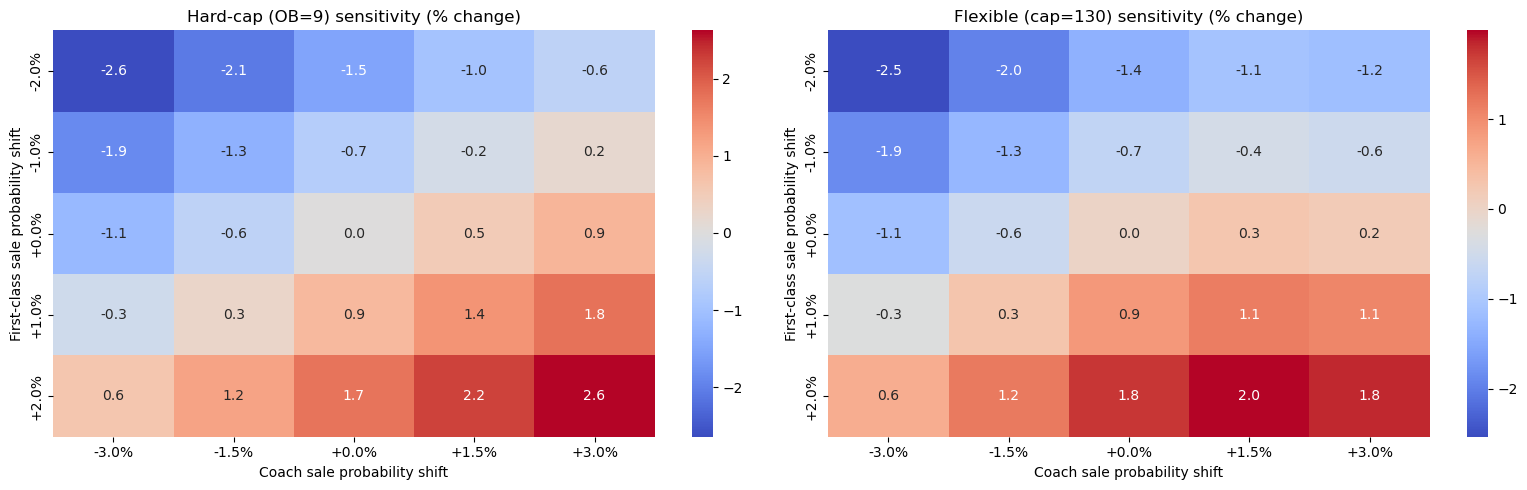

Hard-cap range: -2.6% to 2.6% of baseline
Flexible range: -2.5% to 2.0% of baseline


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(hard_pct, annot=True, fmt='.1f', cmap='coolwarm',
            xticklabels=[f'{x:+.1%}' for x in coach_shifts],
            yticklabels=[f'{x:+.1%}' for x in first_shifts], ax=axes[0])
axes[0].set_title(f'Hard-cap (OB={best_ob}) sensitivity (% change)')
axes[0].set_xlabel('Coach sale probability shift')
axes[0].set_ylabel('First-class sale probability shift')

sns.heatmap(flex_pct, annot=True, fmt='.1f', cmap='coolwarm',
            xticklabels=[f'{x:+.1%}' for x in coach_shifts],
            yticklabels=[f'{x:+.1%}' for x in first_shifts], ax=axes[1])
axes[1].set_title('Flexible (cap=130) sensitivity (% change)')
axes[1].set_xlabel('Coach sale probability shift')
axes[1].set_ylabel('First-class sale probability shift')

plt.tight_layout()
plt.show()

print(f"Hard-cap range: {hard_pct.min():.1f}% to {hard_pct.max():.1f}% of baseline")
print(f"Flexible range: {flex_pct.min():.1f}% to {flex_pct.max():.1f}% of baseline")

**Interpretation:** Coach demand is the dominant driver. A 3-point drop in coach sale probability causes ~3% decline in profit, while first-class shifts have minimal effect. This makes sense because coach accounts for most ticket volume and revenue. No nearby scenario causes a catastrophic collapse — both policies are robust to small estimation errors.

---
## Part 5: Time-Varying Demand (Seasonality)

> **Question:** Assume demand increases as departure approaches. On each day t, multiply the sale probability by `0.75 + t/730`. Re-solve the problem and compare.

### Approach

We modify the Bellman equation so that on each day t, every sale probability is multiplied by `0.75 + t/730`. This means early demand (day 0) is scaled to 75% of baseline, while late demand (day 365) is scaled to ~125%. The terminal condition is unchanged since show-up probabilities are not affected. We re-run the full cap sweep (5 to 20) and the flexible policy with this time-varying factor to see if the optimal cap changes and how profits compare.

In [18]:
# sweep caps with time-varying demand
print("Sweeping overbooking caps with time-varying demand...")
results_tv = {}
for ob in range(5, 21):
    V_tv, U_tv, profit_tv = solve_dp(ob, choices, time_varying=True)
    results_tv[ob] = {'V': V_tv, 'U': U_tv, 'profit': profit_tv}
    print(f"  OB={ob:2d}: ${profit_tv:,.2f}")

best_ob_tv = max(results_tv, key=lambda k: results_tv[k]['profit'])

# flexible with time-varying
V_flex_tv, U_flex_tv, profit_flex_tv = solve_dp(30, choices_flex, time_varying=True)

print(f"\nTime-varying results:")
print(f"  Best hard cap: OB={best_ob_tv}, profit = ${results_tv[best_ob_tv]['profit']:,.2f}")
print(f"  Flexible (cap=130):              profit = ${profit_flex_tv:,.2f}")
print(f"  Flexible improvement:            ${profit_flex_tv - results_tv[best_ob_tv]['profit']:,.2f}")

Sweeping overbooking caps with time-varying demand...
  OB= 5: $41,599.27
  OB= 6: $41,727.52
  OB= 7: $41,804.96
  OB= 8: $41,844.15
  OB= 9: $41,857.70
  OB=10: $41,855.91
  OB=11: $41,845.99
  OB=12: $41,832.53
  OB=13: $41,818.26
  OB=14: $41,804.53
  OB=15: $41,791.91
  OB=16: $41,780.63
  OB=17: $41,770.72
  OB=18: $41,762.16
  OB=19: $41,754.86
  OB=20: $41,748.71

Time-varying results:
  Best hard cap: OB=9, profit = $41,857.70
  Flexible (cap=130):              profit = $41,863.83
  Flexible improvement:            $6.13


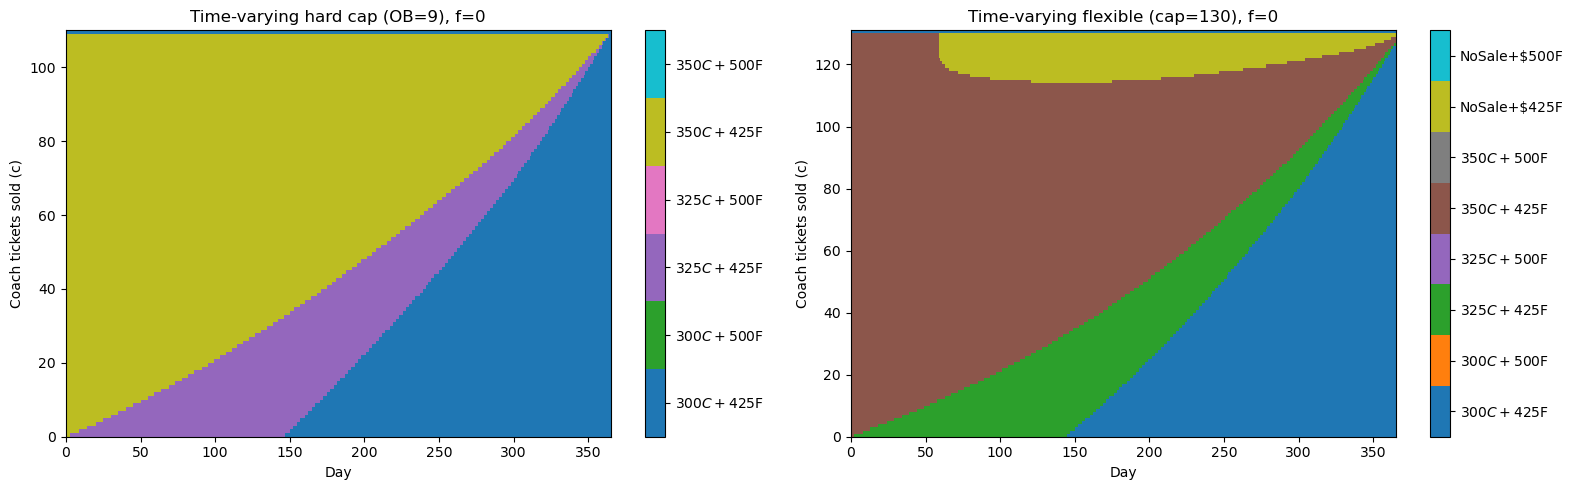

In [19]:
V_best_tv, U_best_tv = results_tv[best_ob_tv]['V'], results_tv[best_ob_tv]['U']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im1 = axes[0].pcolormesh(U_best_tv[:T, :, 0].T, cmap=cmap6, vmin=0.5, vmax=6.5)
cbar1 = fig.colorbar(im1, ax=axes[0], ticks=range(1, 7))
cbar1.ax.set_yticklabels(choice_labels)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Coach tickets sold (c)')
axes[0].set_title(f'Time-varying hard cap (OB={best_ob_tv}), f=0')

im2 = axes[1].pcolormesh(U_flex_tv[:T, :, 0].T, cmap=cmap8, vmin=0.5, vmax=8.5)
cbar2 = fig.colorbar(im2, ax=axes[1], ticks=range(1, 9))
cbar2.ax.set_yticklabels(choice_labels_flex)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Coach tickets sold (c)')
axes[1].set_title('Time-varying flexible (cap=130), f=0')

plt.tight_layout()
plt.show()

**Interpretation:** With time-varying demand (`0.75 + t/730`), early demand is lower and late demand is higher. The optimal cap stays the same. Profits are slightly lower overall because early-period demand is dampened. The policy adapts by being more patient early on and pricing more aggressively closer to departure.

---
## Part 6: Forward Simulation (15,000 Runs)

> **Question:** Simulate the optimal policy forward many times. How often is coach overbooked? How often are passengers kicked off the plane? What is the average overbooking cost? What is the volatility of discounted profits? Do this for both policies.

### Approach

The DP gives us the **expected** profit, but we also want to understand the **distribution** of outcomes — how variable is profit? How often do bad overbooking events actually happen? To answer this, we **simulate forward**: start at (t=0, c=0, f=0), look up the optimal action from U, randomly draw whether a sale occurs, update the state, and repeat for 365 days. At departure, we randomly draw show-ups using the binomial distribution and compute the actual overbooking cost. Running 15,000 independent simulations gives us a distribution of profits, overbooking costs, and other operational metrics.

In [20]:
def simulate_forward(U_policy, max_coach, choices_list, n_sims=15000, time_varying=False, seed=42):
    """Forward-simulate the optimal policy. Returns a DataFrame of outcomes."""
    rng = np.random.default_rng(seed)
    
    coach_sold = np.zeros(n_sims, dtype=int)
    first_sold = np.zeros(n_sims, dtype=int)
    disc_revenue = np.zeros(n_sims)
    
    for sim in range(n_sims):
        c, f = 0, 0
        rev = 0
        for t in range(T):
            action = U_policy[t, c, f]
            if action == 0:
                continue
            cp, c_prob, fp, f_prob = choices_list[action - 1]
            factor = (0.75 + t / 730) if time_varying else 1.0
            
            coach_full = (c == max_coach)
            fc_full = (f == first_class_seats)
            prob_coach = 0 if coach_full else min(1, c_prob * factor)
            prob_first = 0 if fc_full else min(1, f_prob * factor)
            if fc_full and not coach_full and c_prob > 0:
                prob_coach = min(1, prob_coach + fc_sold_out_boost)
            
            if rng.random() < prob_coach:
                c = min(c + 1, max_coach)
                rev += cp * discount**t
            if rng.random() < prob_first:
                f = min(f + 1, first_class_seats)
                rev += fp * discount**t
        
        coach_sold[sim] = c
        first_sold[sim] = f
        disc_revenue[sim] = rev
    
    # departure day show-ups
    coach_showups = rng.binomial(coach_sold, coach_show_prob)
    first_showups = rng.binomial(first_sold, first_show_prob)
    overflow = np.maximum(coach_showups - coach_seats, 0)
    fc_empty = np.maximum(first_class_seats - first_showups, 0)
    bumped = np.minimum(overflow, fc_empty)
    denied = overflow - bumped
    ob_cost = bump_to_fc_cost * bumped + bump_off_plane_cost * denied
    disc_profit = disc_revenue - discount**T * ob_cost
    
    return pd.DataFrame({
        'coach_sold': coach_sold, 'first_sold': first_sold,
        'disc_profit': disc_profit, 'ob_cost': ob_cost,
        'bumped': bumped, 'denied': denied, 'overflow': overflow,
        'sold_above_cap': coach_sold > coach_seats,
    })

In [21]:
# simulate both policies under time-varying demand
print("Simulating hard-cap policy (15,000 runs)...")
sim_hard = simulate_forward(U_best_tv, coach_seats + best_ob_tv, choices,
                            n_sims=15000, time_varying=True, seed=42)

print("Simulating flexible policy (15,000 runs)...")
sim_flex = simulate_forward(U_flex_tv, 130, choices_flex,
                            n_sims=15000, time_varying=True, seed=7)

# summary table
summary = pd.DataFrame({
    'Metric': [
        'Mean discounted profit',
        'Profit volatility (std dev)',
        'Mean overbooking cost',
        'P(sold above 100 coach seats)',
        'P(coach overflow at departure)',
        'P(any passenger denied boarding)',
        'Avg passengers bumped to FC',
        'Avg passengers denied boarding',
    ],
    f'Hard Cap (OB={best_ob_tv})': [
        f"${sim_hard['disc_profit'].mean():,.2f}",
        f"${sim_hard['disc_profit'].std():,.2f}",
        f"${sim_hard['ob_cost'].mean():,.2f}",
        f"{sim_hard['sold_above_cap'].mean():.2%}",
        f"{(sim_hard['overflow']>0).mean():.2%}",
        f"{(sim_hard['denied']>0).mean():.2%}",
        f"{sim_hard['bumped'].mean():.2f}",
        f"{sim_hard['denied'].mean():.2f}",
    ],
    'Flexible (Cap=130)': [
        f"${sim_flex['disc_profit'].mean():,.2f}",
        f"${sim_flex['disc_profit'].std():,.2f}",
        f"${sim_flex['ob_cost'].mean():,.2f}",
        f"{sim_flex['sold_above_cap'].mean():.2%}",
        f"{(sim_flex['overflow']>0).mean():.2%}",
        f"{(sim_flex['denied']>0).mean():.2%}",
        f"{sim_flex['bumped'].mean():.2f}",
        f"{sim_flex['denied'].mean():.2f}",
    ],
})
display(summary)

Simulating hard-cap policy (15,000 runs)...
Simulating flexible policy (15,000 runs)...


,Metric,Hard Cap (OB=9),Flexible (Cap=130)
0,Mean discounted profit,"$41,852.59","$41,858.71"
1,Profit volatility (std dev),$902.41,$905.12
2,Mean overbooking cost,"$1,045.95","$1,083.23"
3,P(sold above 100 coach seats),100.00%,100.00%
4,P(coach overflow at departure),84.63%,85.13%
5,P(any passenger denied boarding),72.83%,74.28%
6,Avg passengers bumped to FC,0.79,0.88
7,Avg passengers denied boarding,2.37,2.44


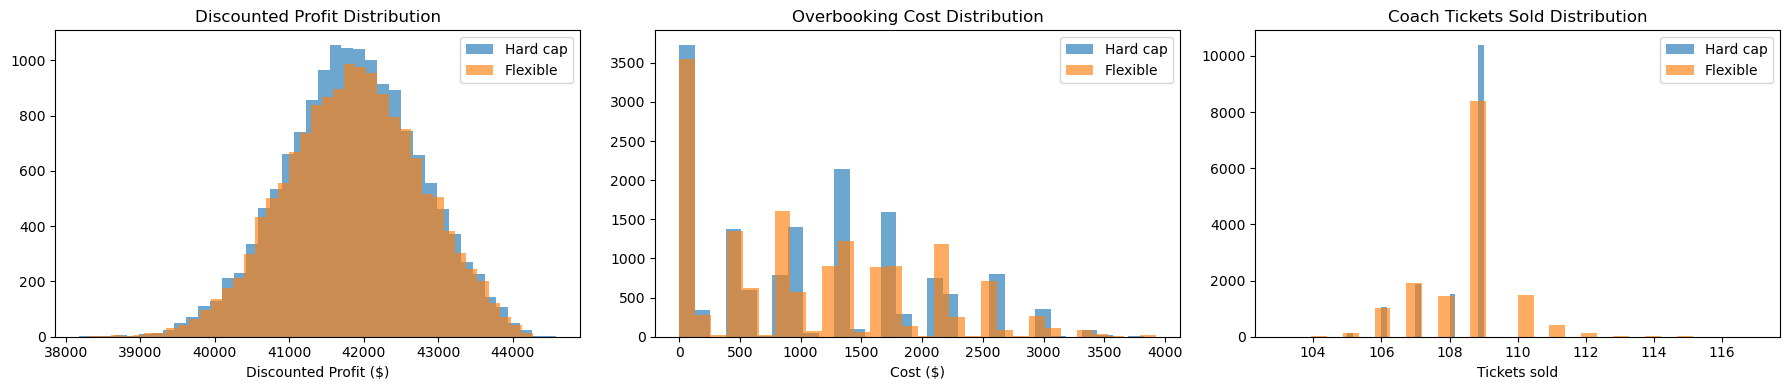

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(sim_hard['disc_profit'], bins=40, alpha=0.65, label='Hard cap')
axes[0].hist(sim_flex['disc_profit'], bins=40, alpha=0.65, label='Flexible')
axes[0].set_title('Discounted Profit Distribution')
axes[0].set_xlabel('Discounted Profit ($)')
axes[0].legend()

axes[1].hist(sim_hard['ob_cost'], bins=30, alpha=0.65, label='Hard cap')
axes[1].hist(sim_flex['ob_cost'], bins=30, alpha=0.65, label='Flexible')
axes[1].set_title('Overbooking Cost Distribution')
axes[1].set_xlabel('Cost ($)')
axes[1].legend()

axes[2].hist(sim_hard['coach_sold'], bins=30, alpha=0.65, label='Hard cap')
axes[2].hist(sim_flex['coach_sold'], bins=30, alpha=0.65, label='Flexible')
axes[2].set_title('Coach Tickets Sold Distribution')
axes[2].set_xlabel('Tickets sold')
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretation:** Both policies produce similar mean discounted profits. Coach is frequently sold above 100 seats under both policies — that's the point of overbooking. Realized overflow at departure happens in a meaningful fraction of flights, but denied boarding is less frequent because empty first-class seats absorb some overflow. The profit distributions overlap heavily, confirming the flexible policy's advantage is marginal.

---
## Part 7: Report to Management

> **Question:** Pretend you are an analyst in the sales department of a major airline. Write a report about the effectiveness of overbooking. Compare and contrast both policies.

In [23]:
display(Markdown(f"""
### Executive Summary: Coach Overbooking Analysis

**Recommendation:** Implement a **hard-cap overbooking policy** allowing up to **{best_ob} extra coach tickets** (total {coach_seats + best_ob} tickets for {coach_seats} seats).

---

#### 1. Overbooking is Profitable

Without overbooking (cap of 5 seats), expected discounted profit is **\${round(V[0,0,0],2):,.2f}**. Allowing up to {best_ob} extra tickets raises this to **\${results[best_ob]['profit']:,.2f}** — an improvement of **\${results[best_ob]['profit'] - round(V[0,0,0],2):,.2f}** ({100*(results[best_ob]['profit']/round(V[0,0,0],2) - 1):.1f}%).

#### 2. The Hard Cap is the Right Choice

We also tested a flexible policy that can stop selling on any day, with a ceiling of 130 coach tickets. It yields **\${profit_flex:,.2f}** — only **\${profit_flex - results[best_ob]['profit']:,.2f}** more than the hard cap. The marginal gain does not justify the added complexity.

#### 3. Profit is Robust to Demand Uncertainty

Sensitivity analysis shows that shifting sale probabilities by up to \u00b13 percentage points changes profit by roughly \u00b13%. No nearby scenario causes a catastrophic loss. Coach demand matters far more than first-class demand.

#### 4. Time-Varying Demand Doesn't Change the Recommendation

Under seasonal demand (probability scaled by `0.75 + t/730`), the optimal hard cap remains at **{best_ob_tv} seats**, and the flexible policy still provides negligible improvement (**\${profit_flex_tv - results_tv[best_ob_tv]['profit']:,.2f}**).

#### 5. Operational Risk Summary (15,000 simulated flights)

| Metric | Hard Cap | Flexible |
|--------|----------|----------|
| Mean discounted profit | \${sim_hard['disc_profit'].mean():,.0f} | \${sim_flex['disc_profit'].mean():,.0f} |
| Mean overbooking cost | \${sim_hard['ob_cost'].mean():,.0f} | \${sim_flex['ob_cost'].mean():,.0f} |
| P(denied boarding) | {(sim_hard['denied']>0).mean():.1%} | {(sim_flex['denied']>0).mean():.1%} |
| Profit volatility | \${sim_hard['disc_profit'].std():,.0f} | \${sim_flex['disc_profit'].std():,.0f} |

#### Bottom Line

A hard cap of **{best_ob} extra coach seats** captures nearly all the profit upside of overbooking while keeping the policy simple and transparent. The flexible policy offers negligible additional profit but increases complexity. **We recommend the hard cap.**
"""))


### Executive Summary: Coach Overbooking Analysis

**Recommendation:** Implement a **hard-cap overbooking policy** allowing up to **9 extra coach tickets** (total 109 tickets for 100 seats).

---

#### 1. Overbooking is Profitable

Without overbooking (cap of 5 seats), expected discounted profit is **\$41,909.75**. Allowing up to 9 extra tickets raises this to **\$42,171.35** — an improvement of **\$261.60** (0.6%).

#### 2. The Hard Cap is the Right Choice

We also tested a flexible policy that can stop selling on any day, with a ceiling of 130 coach tickets. It yields **\$42,177.14** — only **\$5.79** more than the hard cap. The marginal gain does not justify the added complexity.

#### 3. Profit is Robust to Demand Uncertainty

Sensitivity analysis shows that shifting sale probabilities by up to ±3 percentage points changes profit by roughly ±3%. No nearby scenario causes a catastrophic loss. Coach demand matters far more than first-class demand.

#### 4. Time-Varying Demand Doesn't Change the Recommendation

Under seasonal demand (probability scaled by `0.75 + t/730`), the optimal hard cap remains at **9 seats**, and the flexible policy still provides negligible improvement (**\$6.13**).

#### 5. Operational Risk Summary (15,000 simulated flights)

| Metric | Hard Cap | Flexible |
|--------|----------|----------|
| Mean discounted profit | \$41,853 | \$41,859 |
| Mean overbooking cost | \$1,046 | \$1,083 |
| P(denied boarding) | 72.8% | 74.3% |
| Profit volatility | \$902 | \$905 |

#### Bottom Line

A hard cap of **9 extra coach seats** captures nearly all the profit upside of overbooking while keeping the policy simple and transparent. The flexible policy offers negligible additional profit but increases complexity. **We recommend the hard cap.**
